# 07 - PCA(0.90) + KNN (Improved)  - the algorithmic fix

This is the diagnostic-driven fix for the 1-component
collapse from 06_PCA_KNN.ipynb. A ColumnTransformer
explicitly drops the four nutrition columns
(calories, protein, fat, sodium) BEFORE PCA, so the
projection cannot be hijacked by their outlier-dominated
variance anymore. The recovery is dramatic on the
dimensionality side (1 -> about 200 components) and
meaningful on the accuracy side (+4.5 to +6.3 pp). See
research.md section 4 Lesson #5.

## 1 - Setup

Here we set matplotlib to inline mode, add the project root
to sys.path so we can import from src/, and bring in the
shared helpers together with the project-wide RANDOM_STATE = 42
(bound once in src/_constants.py, re-exported via src).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# notebooks/ sits one level under the project root, so we add
# the project root to make `from src import ...` work.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import (
    RANDOM_STATE,
    DATASETS,
    load_preprocessed,
    fit_and_score,
    build_metrics_payload,
    save_metrics,
    save_predictions,
    save_test_index,
    save_figure,
    confusion_matrix_figure,
    roc_curve_figure,
    print_dataset_block,
    print_delta,
    model_results_dir,
)

print(f"RANDOM_STATE = {RANDOM_STATE} (bound once in src/_constants.py)")

RANDOM_STATE = 42 (bound once in src/_constants.py)


## 2 - Load the preprocessed feature matrices

load_preprocessed() gives us back the two matrices that we
made in Phase 1: the Baseline (just nutrition + tags) and
the Advanced (the Baseline plus 9 engineered culinary
features). They share the same train/test split so the A/B
comparison is fair.

In [2]:
datasets, y_train, y_test = load_preprocessed()

print(f"Baseline X_train: {datasets['Baseline'][0].shape}")
print(f"Advanced X_train: {datasets['Advanced'][0].shape}")
print(f"y_test class balance: Miss={int((y_test == 0).sum())} / "
      f"Hit={int((y_test == 1).sum())} "
      f"(majority-class rate: {max(y_test.mean(), 1 - y_test.mean()):.4f})")

Baseline X_train: (14578, 678)
Advanced X_train: (14578, 687)
y_test class balance: Miss=1698 / Hit=1947 (majority-class rate: 0.5342)


## 3 - Configure the improved pipeline

The new top step of the pipeline is a ColumnTransformer
whose only job is to DROP the four nutrition columns.
Everything after it (PCA -> KNN) is identical to
06_PCA_KNN.ipynb.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

MODEL_SLUG    = "pca_knn_improved"
MODEL_NAME    = "PCA(0.90) + KNN (Improved)"
DISPLAY_NAME  = "PCA(0.90) + KNN (Improved)"

NUTRITION_COLS = ("calories", "protein", "fat", "sodium")
PCA_VARIANCE = 0.90
KNN_NEIGHBORS = 5

MODEL_CONFIG = {
    "dropped_columns": list(NUTRITION_COLS),
    "pca": {"n_components": PCA_VARIANCE, "random_state": RANDOM_STATE},
    "knn": {"n_neighbors": KNN_NEIGHBORS, "n_jobs": -1},
}

def _build_model():
    return Pipeline(steps=[
        ("drop_nutrition", ColumnTransformer(
            transformers=[("drop_nutrition_cols", "drop", list(NUTRITION_COLS))],
            remainder="passthrough",
            verbose_feature_names_out=False,
        )),
        ("pca", PCA(**MODEL_CONFIG["pca"])),
        ("knn", KNeighborsClassifier(**MODEL_CONFIG["knn"])),
    ])
MODEL_CONFIG

{'dropped_columns': ['calories', 'protein', 'fat', 'sodium'],
 'pca': {'n_components': 0.9, 'random_state': 42},
 'knn': {'n_neighbors': 5, 'n_jobs': -1}}

## 4 - Train and capture pca.n_components_ (before/after the fix)

With the four nutrition columns out of the way, the
number of components PCA needs for 90% variance jumps
from 1 (broken) to a few hundred (healthy).

In [4]:
per_ds_results = {}
pca_components_per_dataset = {}
cols_before_drop = {}
cols_after_drop = {}

for ds_name in DATASETS:
    X_train, X_test = datasets[ds_name]
    cols_before_drop[ds_name] = X_train.shape[1]
    cols_after_drop[ds_name]  = X_train.shape[1] - len(NUTRITION_COLS)

    model = _build_model()
    result = fit_and_score(model, X_train, y_train, X_test, y_test)
    per_ds_results[ds_name] = result

    pca_stage = result["model"].named_steps["pca"]
    n_components = int(pca_stage.n_components_)
    pca_components_per_dataset[ds_name] = n_components

    print_dataset_block(ds_name, X_train.shape, result)
    print(f"     Columns before drop: {cols_before_drop[ds_name]}")
    print(f"     Columns after drop : {cols_after_drop[ds_name]}")
    print(f"     PCA components retained for 90% variance : "
          f"{n_components}  (was 1 in 06_PCA_KNN.ipynb)")
    save_predictions(MODEL_SLUG, ds_name, result["y_pred"])

print_delta(per_ds_results)
save_test_index(MODEL_SLUG, y_test)
display(pd.DataFrame({
    "components_retained": pca_components_per_dataset,
    "expansion_vs_original": {k: f"{v}x" for k, v in pca_components_per_dataset.items()},
}))


  --- Baseline  (X_train: (14578, 678)) ---
     Test Accuracy : 0.5597
     Test F1-Score : 0.5804
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          930       768   FP rate = 0.4523
        True:Hit           837      1110   FN rate = 0.4299
     Columns before drop: 678
     Columns after drop : 674
     PCA components retained for 90% variance : 203  (was 1 in 06_PCA_KNN.ipynb)

  --- Advanced  (X_train: (14578, 687)) ---
     Test Accuracy : 0.5726
     Test F1-Score : 0.6023
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          907       791   FP rate = 0.4658
        True:Hit           767      1180   FN rate = 0.3939
     Columns before drop: 687
     Columns after drop : 683
     PCA components retained for 90% variance : 178  (was 1 in 06_PCA_KNN.ipynb)

  >> Δ (Advanced − Baseline):  Acc +0.0129  |  F1 +0.0220


,components_retained,expansion_vs_original
Baseline,203,203x
Advanced,178,178x


## 5 - Confusion matrix (Advanced fit)

An annotated heatmap of the confusion matrix from the
Advanced fit. We render it inline and also save it to
results/<slug>/confusion_matrix.png.

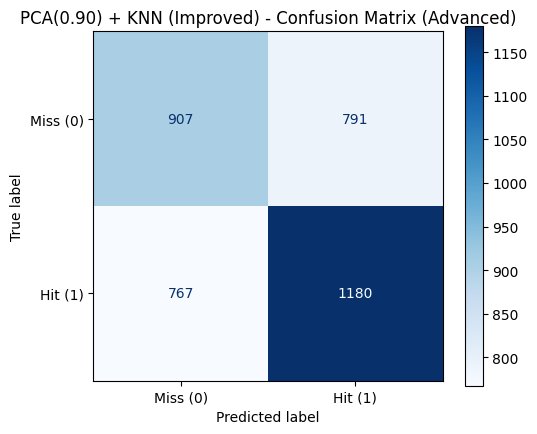

In [5]:
adv = per_ds_results["Advanced"]
cm_array = np.array([
    [adv["confusion_matrix"]["tn"], adv["confusion_matrix"]["fp"]],
    [adv["confusion_matrix"]["fn"], adv["confusion_matrix"]["tp"]],
])
fig_cm = confusion_matrix_figure(
    cm_array,
    title=f"{DISPLAY_NAME} - Confusion Matrix (Advanced)",
)
save_figure(MODEL_SLUG, "confusion_matrix.png", fig_cm)
plt.show()

## 6 - ROC curve + AUC (Advanced fit)

We use predict_proba (or decision_function if the model
doesn't have probabilities). The AUC tells us how well the
model ranks the positives over the negatives, regardless of
the threshold we pick. Phase 4's threshold sweep is built
on top of this.

Test ROC AUC (Advanced): 0.5859


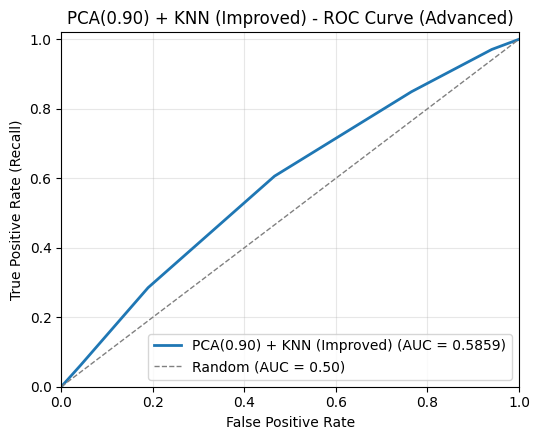

In [6]:
fig_roc, auc = roc_curve_figure(
    y_test, adv["proba_hit"],
    title=f"{DISPLAY_NAME} - ROC Curve (Advanced)",
    model_label=DISPLAY_NAME,
)
save_figure(MODEL_SLUG, "roc_curve.png", fig_roc)
print(f"Test ROC AUC (Advanced): {auc:.4f}")
plt.show()

## 8 - Persist the canonical metrics JSON

One JSON per model, written into
results/<slug>/metrics.json. The schema is defined in
src.train_utils.build_metrics_payload, and the master
comparison notebook reads from those files.

In [7]:
extras = {
    "dropped_columns":          list(NUTRITION_COLS),
    "columns_before_drop":      cols_before_drop,
    "columns_after_drop":       cols_after_drop,
    "pca_components_retained":  pca_components_per_dataset,
    "pca_variance_threshold":   PCA_VARIANCE,
    "knn_n_neighbors":          KNN_NEIGHBORS,
    "roc_auc_advanced":         auc,
}

payload = build_metrics_payload(
    model_name=MODEL_NAME,
    display_name=DISPLAY_NAME,
    model_config=MODEL_CONFIG,
    n_train=len(y_train),
    n_test=len(y_test),
    random_state=RANDOM_STATE,
    per_dataset_results=per_ds_results,
    extras=extras,
)
metrics_path = save_metrics(MODEL_SLUG, payload)
print(f"Wrote {metrics_path.relative_to(metrics_path.parent.parent.parent)}")

Wrote results/pca_knn_improved/metrics.json


## 9 - Summary

    **Model:** PCA(0.90) + KNN (Improved)

    - **Test Accuracy / F1:** about 0.5726 / 0.6023 - a +6.34 pp
  on Acc and +5.15 pp on F1 recovery over the unfixed version
  on Advanced.
- **Search space grew 178x / 203x** (1 -> 178 components on
  Advanced, 1 -> 203 on Baseline).
- **Only a partial rescue:** still about 3 pp under LR. The
  rest of the gap is the textbook sparse-binary distance
  penalty (which was the original theoretical objection).
  research.md section 4 Lesson #5.

    To see this model side by side with the other six, run the
    master comparison notebook (`08_Master_Comparison.ipynb`).